## 1. Import Necessary Libraries.

In [36]:
import tensorflow as tf
import keras
import pandas as pd
from matplotlib import pyplot as plt
import numpy as np
from keras import Sequential
from keras.layers import Conv2D,MaxPool2D,UpSampling2D
from tensorflow.keras.models import load_model

import warnings
warnings.filterwarnings('ignore')

## 2. Import dataset.

In [2]:
(X_train, _), (X_test, _) = keras.datasets.mnist.load_data()
X_train.shape,X_test.shape

((60000, 28, 28), (10000, 28, 28))

## 3. Data Preprocessing.

### 3.1 Add the channel

In [3]:
X_train = X_train.reshape(60000, 28, 28,1)
X_test  = X_test.reshape(10000, 28, 28,1)

In [4]:
X_train.shape,X_test.shape

((60000, 28, 28, 1), (10000, 28, 28, 1))

### 3.2 Normalize DATA

In [5]:
X_train = X_train/255.0
X_test  = X_test/255.0

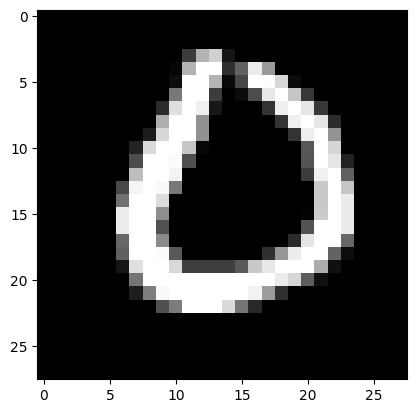

In [6]:
plt.imshow(X_train[2500],cmap = 'gray')

### 3.3 Add Noise

In [7]:
X_train_noise = X_train + 0.25 * np.random.normal(loc=0.0, scale=1.0, size=X_train.shape)
X_test_noise  = X_test + 0.25 * np.random.normal(loc=0.0, scale=1.0, size=X_test.shape)

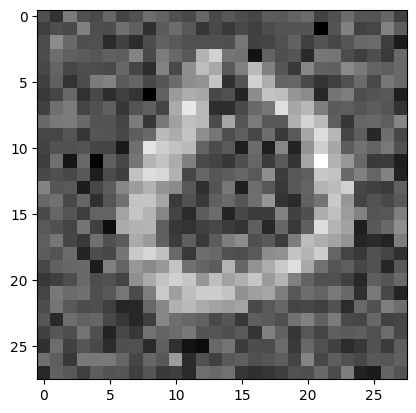

In [8]:
plt.imshow(X_train_noise[2500],cmap = 'gray')

In [9]:
X_train_noise.max(),X_train_noise.min()

(np.float64(2.3544134795862997), np.float64(-1.3402500075936745))

### 3.4 Add the clip

In [10]:
X_train_clipped = np.clip(a=X_train_noise,a_min=0.,a_max=1.) # i will have positive vales
X_test_clipped  = np.clip(a=X_test_noise,a_min=0.,a_max=1.)

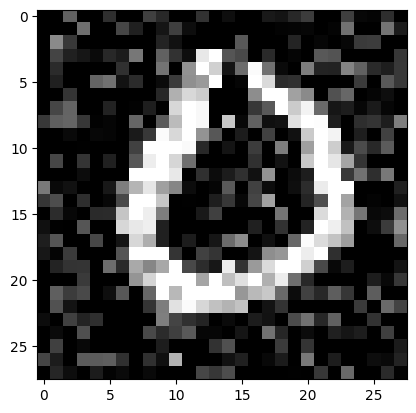

In [11]:
plt.imshow(X_train_clipped[2500],cmap = 'gray')

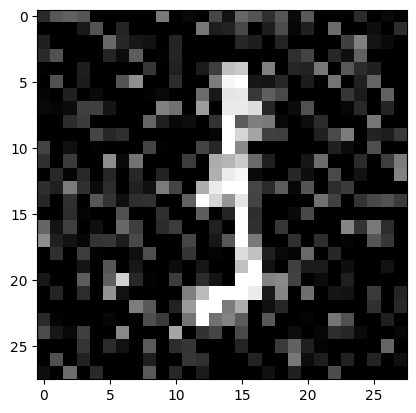

In [12]:
plt.imshow(X_test_clipped[900],cmap = 'gray')

## 4. Model Building

In [13]:
model = Sequential()
#Encoder Block - Compress The info

model.add(Conv2D(filters=32,kernel_size=(3,3),strides=(1, 1),padding='same',activation = 'relu',input_shape=(28,28,1)))
model.add(MaxPool2D(pool_size=(2, 2),))
model.add(Conv2D(filters=8,kernel_size=(3,3),strides=(1, 1),padding='same',activation = 'relu',))
model.add(MaxPool2D(pool_size=(2, 2),))

#Decoder Block - expands the info
model.add(Conv2D(filters=8,kernel_size=(3,3),strides=(1, 1),padding='same',activation = 'relu',))
model.add(UpSampling2D(size=(2, 2),))
model.add(Conv2D(filters=32,kernel_size=(3,3),strides=(1, 1),padding='same',activation = 'relu',))
model.add(UpSampling2D(size=(2, 2),))
model.add(Conv2D(filters=1,kernel_size=(3,3),strides=(1, 1),padding='same',activation = 'relu',))

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                      │ (None, 28, 28, 32)          │             320 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d (MaxPooling2D)         │ (None, 14, 14, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_1 (Conv2D)                    │ (None, 14, 14, 8)           │           2,312 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_1 (MaxPooling2D)       │ (None, 7, 7, 8)             │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_2 (Conv2D)                    │ (None, 7, 7, 8)             │             584 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ up_sampling2d (UpSampling2D)         │ (None, 14, 14, 8)           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_3 (Conv2D)                    │ (None, 14, 14, 32)          │           2,336 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ up_sampling2d_1 (UpSampling2D)       │ (None, 28, 28, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_4 (Conv2D)                    │ (None, 28, 28, 1)           │             289 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 5,841 (22.82 KB)

 Trainable params: 5,841 (22.82 KB)

 Non-trainable params: 0 (0.00 B)

## 5. Model Compilation

In [14]:
model.compile(optimizer='adam',loss='mean_squared_error',metrics=['accuracy'])

## 6. Model Training.

In [15]:
model.fit(x=X_train_clipped,y=X_train,batch_size=32,epochs=5,validation_data=(X_test_clipped,X_test))

Epoch 1/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 77s 39ms/step - accuracy: 0.8132 - loss: 0.0131 - val_accuracy: 0.8133 - val_loss: 0.0083
Epoch 2/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 84s 40ms/step - accuracy: 0.8145 - loss: 0.0078 - val_accuracy: 0.8135 - val_loss: 0.0072
Epoch 3/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 81s 40ms/step - accuracy: 0.8147 - loss: 0.0071 - val_accuracy: 0.8139 - val_loss: 0.0069
Epoch 4/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 68s 33ms/step - accuracy: 0.8148 - loss: 0.0067 - val_accuracy: 0.8139 - val_loss: 0.0065
Epoch 5/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 349s 175ms/step - accuracy: 0.8148 - loss: 0.0065 - val_accuracy: 0.8138 - val_loss: 0.0063


## 7. Model Evalution.

In [19]:
model.evaluate(X_test_clipped,X_test)

313/313 ━━━━━━━━━━━━━━━━━━━━ 8s 27ms/step - accuracy: 0.8138 - loss: 0.0063


[0.00631776824593544, 0.813818097114563]

## 8. Prediction.

In [20]:
y_pred = model.predict(X_test_clipped)

313/313 ━━━━━━━━━━━━━━━━━━━━ 8s 25ms/step


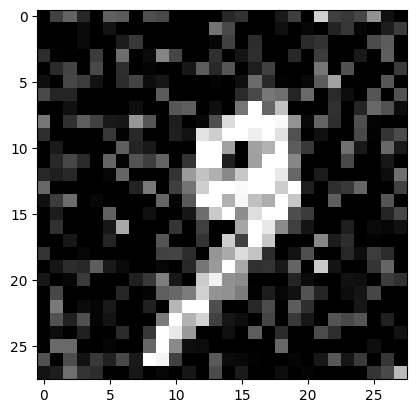

In [26]:
plt.imshow(X_test_clipped[1000],"gray")

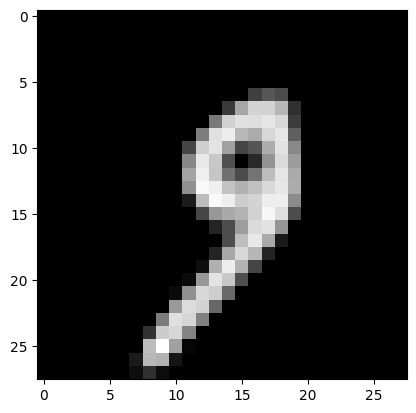

In [27]:
plt.imshow(y_pred[1000],"gray")

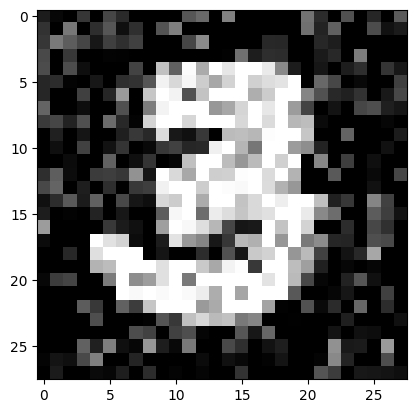

In [31]:
plt.imshow(X_test_clipped[200],"gray")

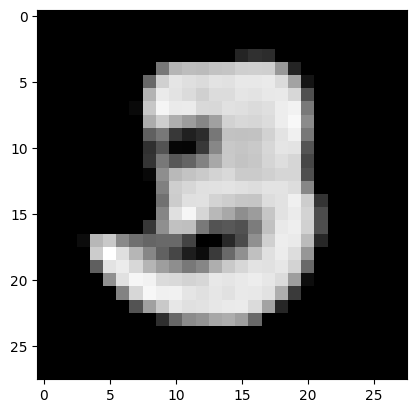

In [43]:
plt.imshow(y_pred[200],"gray")

### 9. Save the model.

In [33]:
model.save("denoising.h5")

In [37]:
denoising_intelligence = load_model("denoising.h5")

In [49]:
def predict_number(X_test_noise):
    X_test_noise = X_test_noise/255.0
    X_test_noise = np.expand_dims(a=X_test_noise,axis=0)
    print(X_test_noise.shape)
    prediction=denoising_intelligence.predict(X_test_noise)
    return np.argmax(prediction)


In [56]:
predict_number(X_test_noise[6])

(1, 28, 28, 1)
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 126ms/step


np.int64(0)

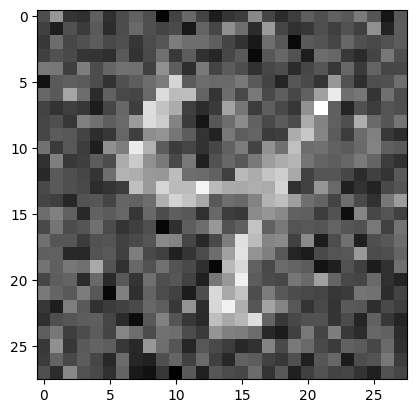

In [57]:
plt.imshow(X_test_noise[6],"gray")

## THE END